In [24]:
import os, math, random, glob
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchinfo
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import time

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#### Synthetic dataset preparation and visualization

##### Helper functions for colors and noise generation

In [26]:
def get_random_color() -> list[int]:
    return np.random.randint(10, 245, size=3).tolist()


def check_contrast(background, foreground) -> list[int]:
    while abs(np.mean(background) - np.mean(foreground)) < 50:
        foreground = get_random_color()
    return foreground


def add_gauss_noise(image) -> np.ndarray:
    noise = np.random.normal(0, 10, image.shape).astype(np.float32)
    image = np.clip(image.astype(np.float32) + noise, 0, 255)
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    return blurred.astype(np.uint8)


def is_far_enough(point, existing_points, distance) -> bool:
    for x, y in existing_points:
        dx = point[0] - x  #
        dy = point[1] - y

        if (dx ** 2 + dy ** 2) < distance ** 2:
            return False

    return True

##### Generating simple shapes
Triangle - 3 random points cv2.fillPoly()

Quadrilateral - 4 random points and call cv2.fillPoly()

Star - 1 random point in the center and 5 random outer points (use a min distance)

In [27]:
def get_triangle_points(width, height, distance) -> list[list[int]]:
    triangle_points = []

    while len(triangle_points) < 3:
        x = np.random.randint(10, width - 10)  #
        y = np.random.randint(10, height - 10)

        if is_far_enough([x, y], triangle_points, distance):
            triangle_points.append([x, y])

    return triangle_points


def get_quadrilateral_points(width, height, distance) -> list[list[int]]:
    quadrilateral_points = []

    while len(quadrilateral_points) < 4:
        x = np.random.randint(5, width - 5)
        y = np.random.randint(5, height - 5)

        if is_far_enough([x, y], quadrilateral_points, distance):
            quadrilateral_points.append([x, y])

    center_x = sum(p[0] for p in quadrilateral_points) / 4
    center_y = sum(p[1] for p in quadrilateral_points) / 4

    quadrilateral_points.sort(key=lambda p: math.atan2(p[1] - center_y, p[0] - center_x))

    return quadrilateral_points


def get_star_points(width, height, distance) -> list[list[int]]:
    center_x = np.random.randint(width // 4, 3 * width // 4)
    center_y = np.random.randint(height // 4, 3 * height // 4)

    star_points = [[center_x, center_y]]
    radius = min(width, height) // 4   # ~32 px for 128x128

    while len(star_points) < 6:
        x = center_x + np.random.randint(-radius, radius)
        y = center_y + np.random.randint(-radius, radius)
        x = max(5, min(x, width - 5))
        y = max(5, min(y, height - 5))
        if is_far_enough([x, y], star_points, distance):
            star_points.append([x, y])
    return star_points

##### Generate complex shapes
Checkerboard - 3x4 grid where each cell is different color from the cell that is sticked to. Keypoints are all the corner's intersections (where different colors meet)

3D cube - pick 1 center point, 3 inner points that are connected to the center(star) and 3 outter points that are edges and connecting to inner points. Then draw 3 quatrilaterals to make it look like 3D cude

In [28]:
def get_checkerboard_points(image, width, height, rows=3, cols=4) -> tuple[list[list[int]], tuple[int, int, int, int]]:
    checkerboard_w = np.random.randint(50, 90)
    checkerboard_h = np.random.randint(40, 80)

    x0 = np.random.randint(10, width - checkerboard_w - 10)
    y0 = np.random.randint(10, height - checkerboard_h - 10)

    cell_w = checkerboard_w // cols
    cell_h = checkerboard_h // rows

    colors = [get_random_color(), None]
    colors[1] = check_contrast(colors[0], get_random_color())

    # grid corners 4 x 5 = 20 keypoints
    checkerboard_points = []
    for row in range(rows + 1):
        for col in range(cols + 1):
            x = x0 + col * cell_w
            y = y0 + row * cell_h
            checkerboard_points.append([x, y])

    # draw cells
    for row in range(rows):
        for col in range(cols):
            x = x0 + col * cell_w
            y = y0 + row * cell_h
            cv2.rectangle(image, (x, y), (x + cell_w, y + cell_h), colors[(row + col) % 2], -1)

    return checkerboard_points, (x0, y0, checkerboard_w, checkerboard_h)


def get_3d_cube(image, width, height) -> list[list[int]]:
    center_x = np.random.randint(width // 4, 3 * width // 4)
    center_y = np.random.randint(height // 4, 3 * height // 4)
    base_angle = np.random.uniform(0, 2 * np.pi)

    inner_points = []
    for step in range(3):
        angle = base_angle + step * (2 * np.pi / 3)
        distance = np.random.randint(12, 25)
        x = int(np.clip(center_x + distance * np.cos(angle), 5, width - 5))
        y = int(np.clip(center_y + distance * np.sin(angle), 5, height - 5))
        inner_points.append([x, y])

    outer_points = []
    for i in range(3):
        point_a = inner_points[i]
        point_b = inner_points[(i + 1) % 3]
        mid_x = (point_a[0] + point_b[0]) / 2
        mid_y = (point_a[1] + point_b[1]) / 2
        push_factor = np.random.uniform(1.2, 1.8)  # depth
        outer_x = int(np.clip(center_x + (mid_x - center_x) * push_factor, 5, width - 5))
        outer_y = int(np.clip(center_y + (mid_y - center_y) * push_factor, 5, height - 5))
        outer_points.append([outer_x, outer_y])

    center = [center_x, center_y]
    I1, I2, I3 = inner_points
    O12, O23, O31 = outer_points

    faces = [[center, I1, O12, I2], [center, I2, O23, I3], [center, I3, O31, I1]]
    for face in faces:
        arr = np.array(face, np.int32)
        cv2.fillPoly(image, [arr], get_random_color())
        cv2.polylines(image, [arr], True, (0, 0, 0), 2)

    return [center] + inner_points + outer_points

##### Generate images

In [29]:
def generate_image_with_shape(shape, width, height) -> tuple[np.ndarray, list[list[int]]]:
    background = get_random_color()
    image = np.full((height, width, 3), background, np.uint8)
    foreground = check_contrast(background, get_random_color())

    if shape == 'triangle':
        keypoints = get_triangle_points(width, height, 10)
        cv2.fillPoly(image, [np.array(keypoints, np.int32)], foreground)
    elif shape == 'quadrilateral':
        keypoints = get_quadrilateral_points(width, height, 10)
        cv2.fillPoly(image, [np.array(keypoints, np.int32)], foreground)
    elif shape == 'star':
        keypoints = get_star_points(width, height, 10)
        for point in keypoints[1:]:  # draw lines from center to each outer point
            cv2.line(image, tuple(map(int, keypoints[0])), tuple(map(int, point)), foreground, 2)
    elif shape == 'chessboard':
        keypoints, box = get_checkerboard_points(image, width, height)
    elif shape == 'cube':
        keypoints = get_3d_cube(image, width, height)
    else:
        raise ValueError(shape)

    return add_gauss_noise(image), keypoints


def generate_image_with_more_shapes(width, height, num_shapes) -> tuple[np.ndarray, list[list[int]]]:
    background = get_random_color()
    image = np.full((height, width, 3), background, np.uint8)
    occupied_part = np.zeros((height, width), np.uint8)
    keypoints_in_image = []

    for _ in range(num_shapes):
        for _ in range(20):
            shape_type = np.random.choice(['triangle', 'quadrilateral', 'star'])

            if shape_type == 'triangle':
                points = get_triangle_points(width, height, distance=20)
            elif shape_type == 'quadrilateral':
                points = get_quadrilateral_points(width, height, distance=20)
            else:
                points = get_star_points(width, height, distance=20)

            temp_mask = np.zeros_like(occupied_part)
            if shape_type == 'star':
                for point in points[1:]:
                    cv2.line(temp_mask, tuple(map(int, points[0])), tuple(map(int, point)), 255, 3)
            else:
                cv2.fillPoly(temp_mask, [np.array(points, np.int32)], 255)

            if np.any(occupied_part & temp_mask):
                continue  # overlaps

            # no overlap draw it
            color = check_contrast(background, get_random_color())
            if shape_type == 'star':
                for point in points[1:]:
                    cv2.line(image, tuple(map(int, points[0])), tuple(map(int, point)), color, 2)
            else:
                cv2.fillPoly(image, [np.array(points, np.int32)], color)

            occupied_part |= temp_mask
            keypoints_in_image.extend(points)
            break

    return add_gauss_noise(image), keypoints_in_image


##### Homography augmentation
This should happen during data generation and durng homographic adaptation

In [30]:
def generate_random_homography(width, height, min_distance=25) -> np.ndarray:
    center_x = width // 2
    center_y = height // 2

    quadrants = [
        (0, center_x, 0, center_y),  # tl
        (center_x, width, 0, center_y),  # tr
        (center_x, width, center_y, height),  # br
        (0, center_x, center_y, height),  # bl
    ]

    original_points = []
    for x_min, x_max, y_min, y_max in quadrants:
        while True:
            x = np.random.randint(x_min, x_max)
            y = np.random.randint(y_min, y_max)
            if is_far_enough([x, y], [[center_x, center_y]], min_distance):
                original_points.append([x, y])
                break

    # 0, 90, 180, 270
    rotated_points = np.roll(original_points, shift=np.random.randint(0, 4), axis=0)

    original = np.array(rotated_points, np.float32)
    transformed = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], np.float32)  #

    return cv2.getPerspectiveTransform(original, transformed)


def apply_homography(image, keypoints, width,height):
    homography = generate_random_homography(width, height)

    warped_image = cv2.warpPerspective(image, homography, (width, height))

    warped_keypoints = []
    for x, y in keypoints:
        homogeneous_point = np.array([x, y, 1], dtype=np.float32)
        transformed = homography @ homogeneous_point
        new_x = transformed[0] / transformed[2]
        new_y = transformed[1] / transformed[2]

        # points inside the image
        if 0 <= new_x < width and 0 <= new_y < height:
            warped_keypoints.append([int(new_x), int(new_y)])

    return warped_image, warped_keypoints


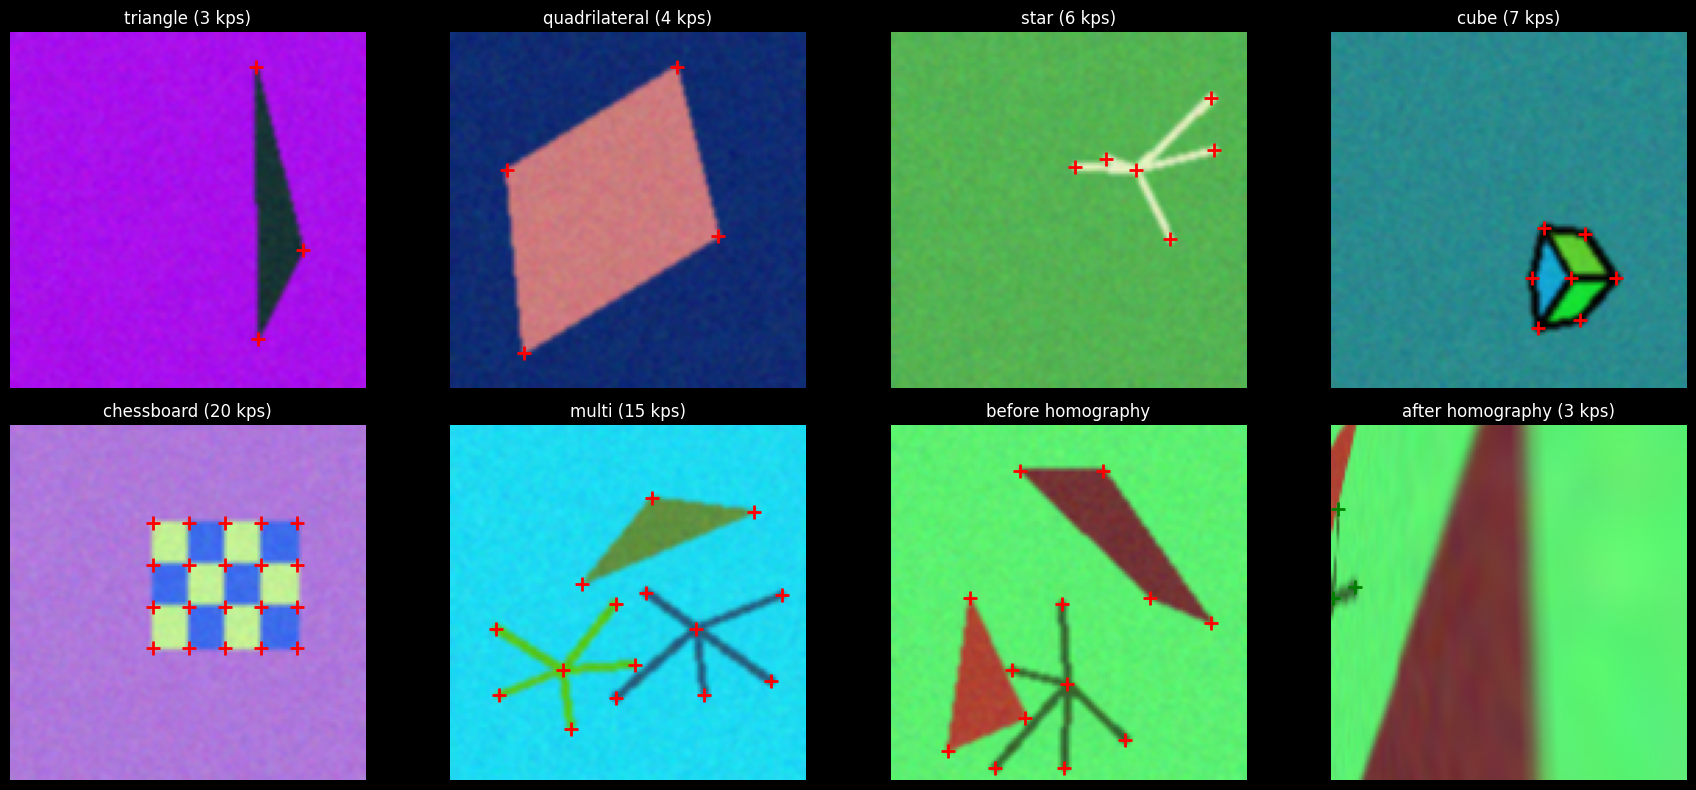

In [31]:
def show_sample_grid():
    IMG_W, IMG_H = 128, 128
    fig, axs = plt.subplots(2, 4, figsize=(18, 8))

    for ax, s in zip(axs[0], ['triangle', 'quadrilateral', 'star', 'cube']):
        image, keypoints = generate_image_with_shape(s, IMG_W, IMG_H)
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        for x, y in keypoints:
            ax.plot(x, y, 'r+', ms=10, mew=2)
        ax.set_title(f'{s} ({len(keypoints)} kps)')
        ax.axis('off')

    image, keypoints = generate_image_with_shape('chessboard', IMG_W, IMG_H)
    axs[1, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for x, y in keypoints:
        axs[1, 0].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 0].set_title(f'chessboard ({len(keypoints)} kps)')
    axs[1, 0].axis('off')

    image, keypoints = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    axs[1, 1].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for x, y in keypoints:
        axs[1, 1].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 1].set_title(f'multi ({len(keypoints)} kps)')
    axs[1, 1].axis('off')

    image, keypoints = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    img2, kps2 = apply_homography(image, keypoints, IMG_W, IMG_H)
    axs[1, 2].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for x, y in keypoints:
        axs[1, 2].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 2].set_title('before homography')
    axs[1, 2].axis('off')

    axs[1, 3].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    for x, y in kps2:
        axs[1, 3].plot(x, y, 'g+', ms=10, mew=2)
    axs[1, 3].set_title(f'after homography ({len(kps2)} kps)')
    axs[1, 3].axis('off')

    plt.tight_layout()
    plt.show()


show_sample_grid()


#### Neural Network
Building neurla network that has encoder and decoder

##### ResNet block
ResNet block is built from Conv - BatchNorm - ReLu - Conv - BatchNorm - ReLu. Its key idea is the skip connection (residual connection), where the input is added to the output of the block.
If the number of input and output channels is different, a 1﷿﷿1 convolution is used to match dimensions before the addition.
This skip connection helps prevent vanishing gradients and makes training deep networks more stable. The skip connection preserves the original signal and improves gradient flow, making it easier for the network to learn useful transformations.

In [32]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.convolution1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.batchNorm1 = nn.BatchNorm2d(out_channels)
        self.convolution2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.batchNorm2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if in_channels != out_channels:
            self.identity = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
        else:
            self.identity = nn.Identity()

    def forward(self, x):
        identity = self.identity(x)
        out = self.convolution1(x)
        out = self.batchNorm1(out)
        out = self.relu(out)
        out = self.convolution2(out)
        out = self.batchNorm2(out)
        out += identity
        out = self.relu(out)

        return out

##### Encoder
The encoder is built from 3x(ResNet block -> MaxPoll) and at the end 2xResNet block.

The output from the encoder for a 240x320 image is 30 x 40 x 128. Each pixel in this 30x40 output coresponds to an 8x8 region in the original image (240/30 = 8 and 320/40 = 8) and each of these 128 values decribes everything the newtwork saw in that 8x8 patch of the original images. Then the decoder uses these vectors to decide if there was a keypoint in this 8x8 cell and if yes where?

In [33]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            ResNetBlock(1, 64),  # grayscale
            ResNetBlock(64, 64),
            nn.MaxPool2d(2),

            ResNetBlock(64, 64),
            ResNetBlock(64, 64),
            nn.MaxPool2d(2),

            ResNetBlock(64, 128),
            ResNetBlock(128, 128),
            nn.MaxPool2d(2),

            ResNetBlock(128, 128),
            ResNetBlock(128, 128),
        )

    def forward(self, x):
        return self.body(x)

##### Decoder
The decoder is built from Conv(128 -> 256), BatchNorm, ReLu and Conv(256 -> 65)

The output of the decoder is (B, 65, H/8, W/8) logits, used for training.  The 65 are 64 possible positions withing the 8x8  cells and  +1 cell with no keypoint

In [34]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 65, kernel_size=1, bias=False),
        )

    def forward(self, x):
        return self.body(x)

##### SuperPoint detector
The model will return logits that will be used to train, then when using the model the output from the model should be set  under softmax, the last channel (65th) should be dropped  and the 64 channels should be rearranged, to get full HxW heatmap

In [35]:
class SuperPointDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x  # (B, 65, Hc, Wc)

In [36]:
model = SuperPointDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
writer = SummaryWriter('runs/superpoint')

print(torchinfo.summary(model, [1, 1, 128, 128], device=device,
                        depth=4,
                        col_names=("input_size", "output_size", "num_params", "mult_adds"),
                        ))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
SuperPointDetector                       [1, 1, 128, 128]          [1, 65, 16, 16]           --                        --
├─Encoder: 1-1                           [1, 1, 128, 128]          [1, 128, 16, 16]          --                        --
│    └─Sequential: 2-1                   [1, 1, 128, 128]          [1, 128, 16, 16]          --                        --
│    │    └─ResNetBlock: 3-1             [1, 1, 128, 128]          [1, 64, 128, 128]         --                        --
│    │    │    └─Conv2d: 4-1             [1, 1, 128, 128]          [1, 64, 128, 128]         64                        1,048,576
│    │    │    └─Conv2d: 4-2             [1, 1, 128, 128]          [1, 64, 128, 128]         576                       9,437,184
│    │    │    └─BatchNorm2d: 4-3        [1, 64, 128, 128]         [1, 64, 128, 128]         128                       128
│ 

#### Synthetic Dataset

In [37]:
def keypoints_to_grid(mask: np.ndarray) -> np.ndarray:
    height, width = mask.shape
    height_cell, width_cell = height // 8, width // 8

    m = mask.reshape(height_cell, 8, width_cell, 8)  # (Hc, 8, Wc, 8)
    m = np.transpose(m, (0, 2, 1, 3))  # (Hc, Wc, 8, 8)
    m = m.reshape(height_cell, width_cell, 64)  # (Hc, Wc, 64)

    grid = np.zeros((height_cell, width_cell, 65), dtype=np.float32)
    grid[..., 64] = 1.0

    for i in range(height_cell):
        for j in range(width_cell):
            keypoint_positions = np.where(m[i, j] > 0)[0]  # which of 64 positions has keypoint

            if len(keypoint_positions) > 0: # one hot
                keep_keypoint = np.random.choice(keypoint_positions)
                grid[i, j, :] = 0
                grid[i, j, keep_keypoint] = 1.0

    return grid

In [38]:
class SyntheticDataset(Dataset):
    def __init__(self, width=128, height=128, homography_probability=0.7):
        self.width = width
        self.height = height
        self.homography_probability = homography_probability

    def generate_random_sample(self):
        mode = np.random.choice(['simple', 'complex', 'multi'], p=[0.4, 0.4, 0.2])

        if mode == 'simple':
            shape = np.random.choice(['triangle', 'quadrilateral', 'star'])
            return generate_image_with_shape(shape, self.width, self.height)
        elif mode == 'complex':
            shape = np.random.choice(['chessboard', 'cube'])
            return generate_image_with_shape(shape, self.width, self.height)
        else:
            return generate_image_with_more_shapes(self.width, self.height, 3)

    def __len__(self):
        return 9999999  # infinite

    def __getitem__(self, idx):
        image, keypoints = self.generate_random_sample()

        if np.random.rand() < self.homography_probability:
            image, keypoints = apply_homography(image, keypoints, self.width, self.height)

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(gray).unsqueeze(0) # (1, H, W)

        #  keypoints to binary mask (H, W)
        mask = np.zeros((self.height, self.width), dtype=np.float32)
        for x, y in keypoints:
            if 0 <= x < self.width and 0 <= y < self.height:
                mask[int(y), int(x)] = 1.0

        label = keypoints_to_grid(mask) # (H, W, 65)
        label_tensor = torch.from_numpy(label).permute(2, 0, 1).float() # (65, Hc, Wc)

        return image_tensor, label_tensor


#### Training, loss and visualization

##### Loss
For los is used cross entropy using logits (pre softmax values)

In [39]:
def loss_fun(logits, target):
    idx_with_highest_val = torch.argmax(target, dim=1)
    return F.cross_entropy(logits, idx_with_highest_val)

##### Training


In [40]:
MAX_ITERS = 200000
BATCH_SIZE = 16

dataset = SyntheticDataset(128, 128, homography_probability=0.7)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=0, drop_last=True)

model = SuperPointDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

loss_history = []
best_loss = float('inf')

iteration = 0
model.train()

data_iter = iter(loader)

while iteration < MAX_ITERS:

    # restart loader ONLY when exhausted
    try:
        image, target = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        image, target = next(data_iter)

    image = image.to(device)
    target = target.to(device)

    start_time = time.time()

    optimizer.zero_grad()
    logits = model(image)
    loss = loss_fun(logits, target)
    loss.backward()
    optimizer.step()

    elapsed_ms = (time.time() - start_time) * 1000

    loss_history.append(loss.item())
    iteration +=1

    if loss.item() < best_loss:
        best_loss = loss.item()

    if iteration % 100 == 0:
        print(f'[Iter {iteration}/{MAX_ITERS}] | Loss: {loss.item():.4f} | Time: {elapsed_ms:.2f} ms')

torch.save({
    'model_state_dict': model.state_dict(),
    'iteration': iteration,
    'best_loss': best_loss,
    'loss_history': loss_history
}, 'models/model_final.pth')

print(f'\nDone. Best loss = {best_loss:.4f}')

[Iter 100/200000] | Loss: 0.1997 | Time: 13.23 ms
[Iter 200/200000] | Loss: 0.1341 | Time: 19.26 ms
[Iter 300/200000] | Loss: 0.1180 | Time: 12.24 ms
[Iter 400/200000] | Loss: 0.0759 | Time: 17.20 ms
[Iter 500/200000] | Loss: 0.0706 | Time: 12.87 ms
[Iter 600/200000] | Loss: 0.0794 | Time: 12.20 ms
[Iter 700/200000] | Loss: 0.0955 | Time: 11.34 ms
[Iter 800/200000] | Loss: 0.0880 | Time: 15.86 ms
[Iter 900/200000] | Loss: 0.1065 | Time: 12.94 ms
[Iter 1000/200000] | Loss: 0.0669 | Time: 14.51 ms
[Iter 1100/200000] | Loss: 0.0888 | Time: 12.69 ms
[Iter 1200/200000] | Loss: 0.0644 | Time: 13.96 ms
[Iter 1300/200000] | Loss: 0.0493 | Time: 13.97 ms
[Iter 1400/200000] | Loss: 0.0762 | Time: 18.09 ms
[Iter 1500/200000] | Loss: 0.0696 | Time: 12.81 ms
[Iter 1600/200000] | Loss: 0.0705 | Time: 16.69 ms
[Iter 1700/200000] | Loss: 0.0632 | Time: 21.55 ms
[Iter 1800/200000] | Loss: 0.0537 | Time: 12.47 ms
[Iter 1900/200000] | Loss: 0.0650 | Time: 16.75 ms
[Iter 2000/200000] | Loss: 0.0681 | Time

C:\Users\Andrea Korunoska\AppData\Local\Temp\ipykernel_25304\808183453.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  new_x = transformed[0] / transformed[2]
C:\Users\Andrea Korunoska\AppData\Local\Temp\ipykernel_25304\808183453.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  new_y = transformed[1] / transformed[2]


[Iter 91100/200000] | Loss: 0.0205 | Time: 29.42 ms
[Iter 91200/200000] | Loss: 0.0224 | Time: 17.97 ms
[Iter 91300/200000] | Loss: 0.0582 | Time: 15.41 ms
[Iter 91400/200000] | Loss: 0.0381 | Time: 15.92 ms
[Iter 91500/200000] | Loss: 0.0365 | Time: 13.62 ms
[Iter 91600/200000] | Loss: 0.0519 | Time: 13.75 ms
[Iter 91700/200000] | Loss: 0.0485 | Time: 22.55 ms
[Iter 91800/200000] | Loss: 0.0297 | Time: 16.12 ms
[Iter 91900/200000] | Loss: 0.0324 | Time: 13.11 ms
[Iter 92000/200000] | Loss: 0.0416 | Time: 10.15 ms
[Iter 92100/200000] | Loss: 0.0240 | Time: 14.17 ms
[Iter 92200/200000] | Loss: 0.0265 | Time: 16.13 ms
[Iter 92300/200000] | Loss: 0.0310 | Time: 15.27 ms
[Iter 92400/200000] | Loss: 0.0293 | Time: 16.98 ms
[Iter 92500/200000] | Loss: 0.0217 | Time: 14.93 ms
[Iter 92600/200000] | Loss: 0.0345 | Time: 14.28 ms
[Iter 92700/200000] | Loss: 0.0461 | Time: 13.68 ms
[Iter 92800/200000] | Loss: 0.0281 | Time: 19.63 ms
[Iter 92900/200000] | Loss: 0.0348 | Time: 12.47 ms
[Iter 93000/

C:\Users\Andrea Korunoska\AppData\Local\Temp\ipykernel_25304\808183453.py:39: RuntimeWarning: invalid value encountered in scalar divide
  new_x = transformed[0] / transformed[2]


[Iter 99800/200000] | Loss: 0.0276 | Time: 11.94 ms
[Iter 99900/200000] | Loss: 0.0161 | Time: 7.67 ms
[Iter 100000/200000] | Loss: 0.0298 | Time: 19.04 ms
[Iter 100100/200000] | Loss: 0.0256 | Time: 21.15 ms
[Iter 100200/200000] | Loss: 0.0382 | Time: 14.03 ms
[Iter 100300/200000] | Loss: 0.0302 | Time: 10.12 ms
[Iter 100400/200000] | Loss: 0.0246 | Time: 8.08 ms
[Iter 100500/200000] | Loss: 0.0551 | Time: 12.93 ms
[Iter 100600/200000] | Loss: 0.0384 | Time: 11.79 ms
[Iter 100700/200000] | Loss: 0.0293 | Time: 15.49 ms
[Iter 100800/200000] | Loss: 0.0315 | Time: 15.42 ms
[Iter 100900/200000] | Loss: 0.0332 | Time: 13.95 ms
[Iter 101000/200000] | Loss: 0.0407 | Time: 16.35 ms
[Iter 101100/200000] | Loss: 0.0216 | Time: 20.52 ms
[Iter 101200/200000] | Loss: 0.0217 | Time: 16.46 ms
[Iter 101300/200000] | Loss: 0.0229 | Time: 13.41 ms
[Iter 101400/200000] | Loss: 0.0332 | Time: 14.92 ms
[Iter 101500/200000] | Loss: 0.0256 | Time: 14.18 ms
[Iter 101600/200000] | Loss: 0.0414 | Time: 16.12 

##### Loss visualization

In [41]:
def plot_loss(loss_history, smoothing_window=100):
    loss = np.array(loss_history, dtype=float)

    # moving avg
    if len(loss) >= smoothing_window:
        smoothed = np.convolve(loss, np.ones(smoothing_window) / smoothing_window, mode='valid')
        smoothed_start = smoothing_window - 1
    else:
        smoothed = loss
        smoothed_start = 0

    plt.figure(figsize=(10, 5))
    plt.plot(loss, alpha=0.4, label='Raw loss')
    plt.plot(range(smoothed_start, smoothed_start + len(smoothed)), smoothed,
             label=f'Smoothed (window={smoothing_window})')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('SuperPoint Training Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

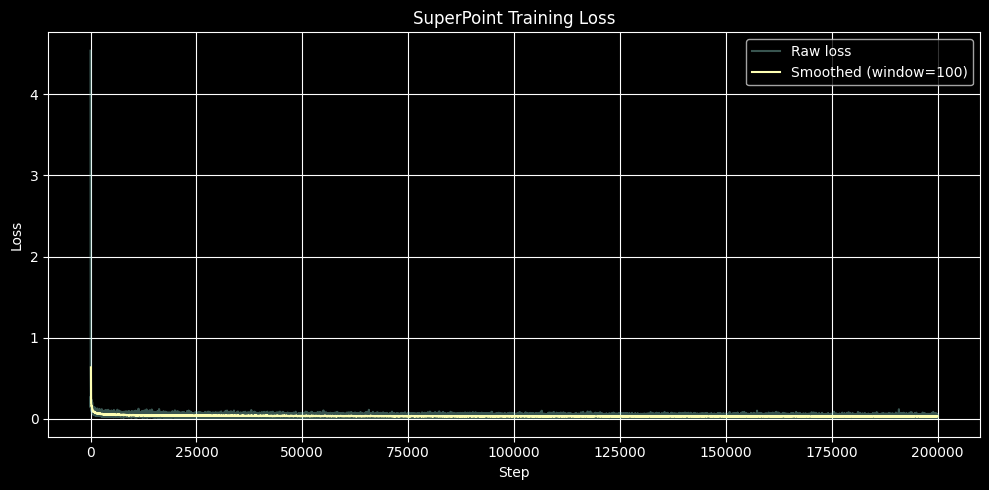

In [42]:
plot_loss(loss_history)

#### Results visualization
logits_to_heatmap -> it is used post processing, so the logits are better presneted (visuality) on a heatmap. The heatmap is telling us where on the images we have valuable points

In [43]:
def logits_to_heatmap(logits):
    batch_size, _, height_cells, width_cells = logits.shape

    probabilities = F.softmax(logits, dim=1)[:, :-1]  # drop dustbin;  (B, 64, Hc, Wc)
    probabilities = probabilities.view(batch_size, 8, 8, height_cells, width_cells) # 64 back to square 8 x 8;  (B, 8, 8, Hc, Wc)
    probabilities = probabilities.permute(0, 3, 1, 4, 2)  # (B, Hc, 8, Wc, 8)
    heatmap = probabilities.reshape(batch_size, 1, height_cells * 8, width_cells * 8) # (B, 1, H, W)

    return heatmap


def get_keypoints_from_heatmap(heatmap, percentile=99.5, nms_radius=4, max_keypoints=500):
    probability_map = heatmap[0, 0].cpu().numpy()  # 320 x 240

    threshold_value = float(np.percentile(probability_map, percentile))
    is_strong_enough = probability_map > threshold_value

    if not np.any(is_strong_enough):
        return [], probability_map

    window_size = 2 * nms_radius + 1
    kernel = np.ones((window_size, window_size), np.uint8) # 9x9
    max_in_neighborhood = cv2.dilate(probability_map, kernel) # 320 x 240

    is_local_maximum = (probability_map == max_in_neighborhood) # 320 x 240 and T on local_maximums

    final_candidates_mask = is_strong_enough & is_local_maximum # 320 x 240

    y_coords, x_coords = np.where(final_candidates_mask)

    point_list = []
    for i in range(len(x_coords)):
        x, y = x_coords[i], y_coords[i]
        score = probability_map[y, x]
        point_list.append((x, y, score))

    point_list.sort(key=lambda p: p[2], reverse=True)

    final_keypoints = []
    for p in point_list[:max_keypoints]:
        final_keypoints.append((int(p[0]), int(p[1])))

    return final_keypoints, probability_map


def load_model(path='models/model_final.pth'):
    checkpoint = torch.load(path, map_location=device)
    model = SuperPointDetector().to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(
        f'loaded model from {path} (iteration={checkpoint.get("iteration")}, loss={checkpoint.get("loss_history", [0])[-1]:.4f})')
    return model

##### Predictions on synthetic samples

In [44]:
def show_predictions(model, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

    for row in range(num_samples):
        image, ground_truth_keypoints = generate_image_with_more_shapes(128, 128, 4)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(image_tensor)
            heatmap = logits_to_heatmap(logits)

        predicted_keypoints, prob_map = get_keypoints_from_heatmap(heatmap)

        # ground truth
        axes[row, 0].imshow(gray, cmap='gray')
        for x, y in ground_truth_keypoints:
            axes[row, 0].plot(x, y, 'r+', ms=8, mew=1.5)
        axes[row, 0].set_title(f'Ground truth ({len(ground_truth_keypoints)} keypoints)')
        axes[row, 0].axis('off')

        # heatmap
        axes[row, 1].imshow(prob_map, cmap='jet')
        axes[row, 1].set_title('Heatmap')
        axes[row, 1].axis('off')

        # predictions
        axes[row, 2].imshow(gray, cmap='gray')
        for x, y in predicted_keypoints:
            axes[row, 2].plot(x, y, 'g+', ms=8, mew=1.5)
        axes[row, 2].set_title(f'Predicted ({len(predicted_keypoints)} keypoints)')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()

#### Homographic adaptation

In [45]:
def homographic_adaptation(model, image, num_homographies=99):
    h, w = image.shape
    total_heatmap = np.zeros((h, w), dtype=np.float32)
    total_counts = np.zeros((h, w), dtype=np.float32)

    mask_ones = np.ones((h, w), dtype=np.float32)

    with torch.no_grad():
        input_tensor = torch.from_numpy(image).view(1, 1, h, w).to(device)
        original_prediction = logits_to_heatmap(model(input_tensor))[0, 0].cpu().numpy()

    total_heatmap += original_prediction
    total_counts += mask_ones

    for _ in range(num_homographies):
        H = generate_random_homography(w, h)
        warped_img = cv2.warpPerspective(image, H, (w, h))

        with torch.no_grad():
            warped_tensor = torch.from_numpy(warped_img).view(1, 1, h, w).to(device)
            warped_heatmap = logits_to_heatmap(model(warped_tensor))[0, 0].cpu().numpy()

        H_inv = np.linalg.inv(H)
        heatmap_back = cv2.warpPerspective(warped_heatmap, H_inv, (w, h))

        pixels_back = cv2.warpPerspective(mask_ones, H_inv, (w, h), flags=cv2.INTER_NEAREST)

        total_heatmap += heatmap_back
        total_counts += pixels_back

    final_heatmap = total_heatmap / np.maximum(total_counts, 1.0)

    return final_heatmap

#### Demo on real photo

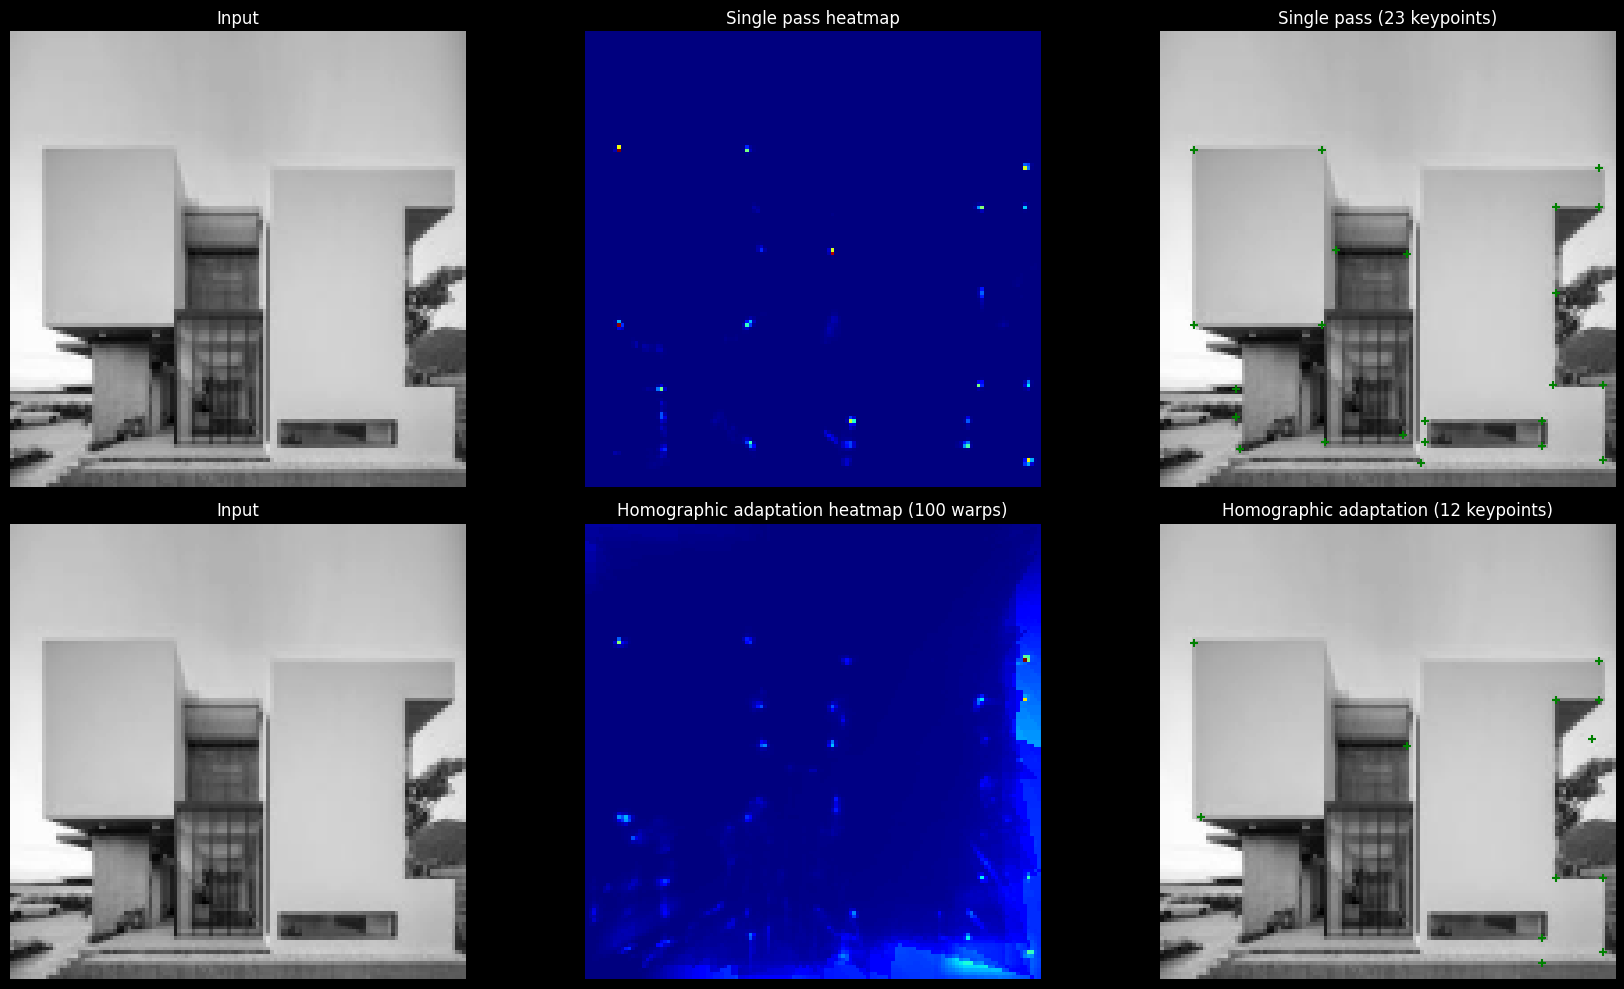

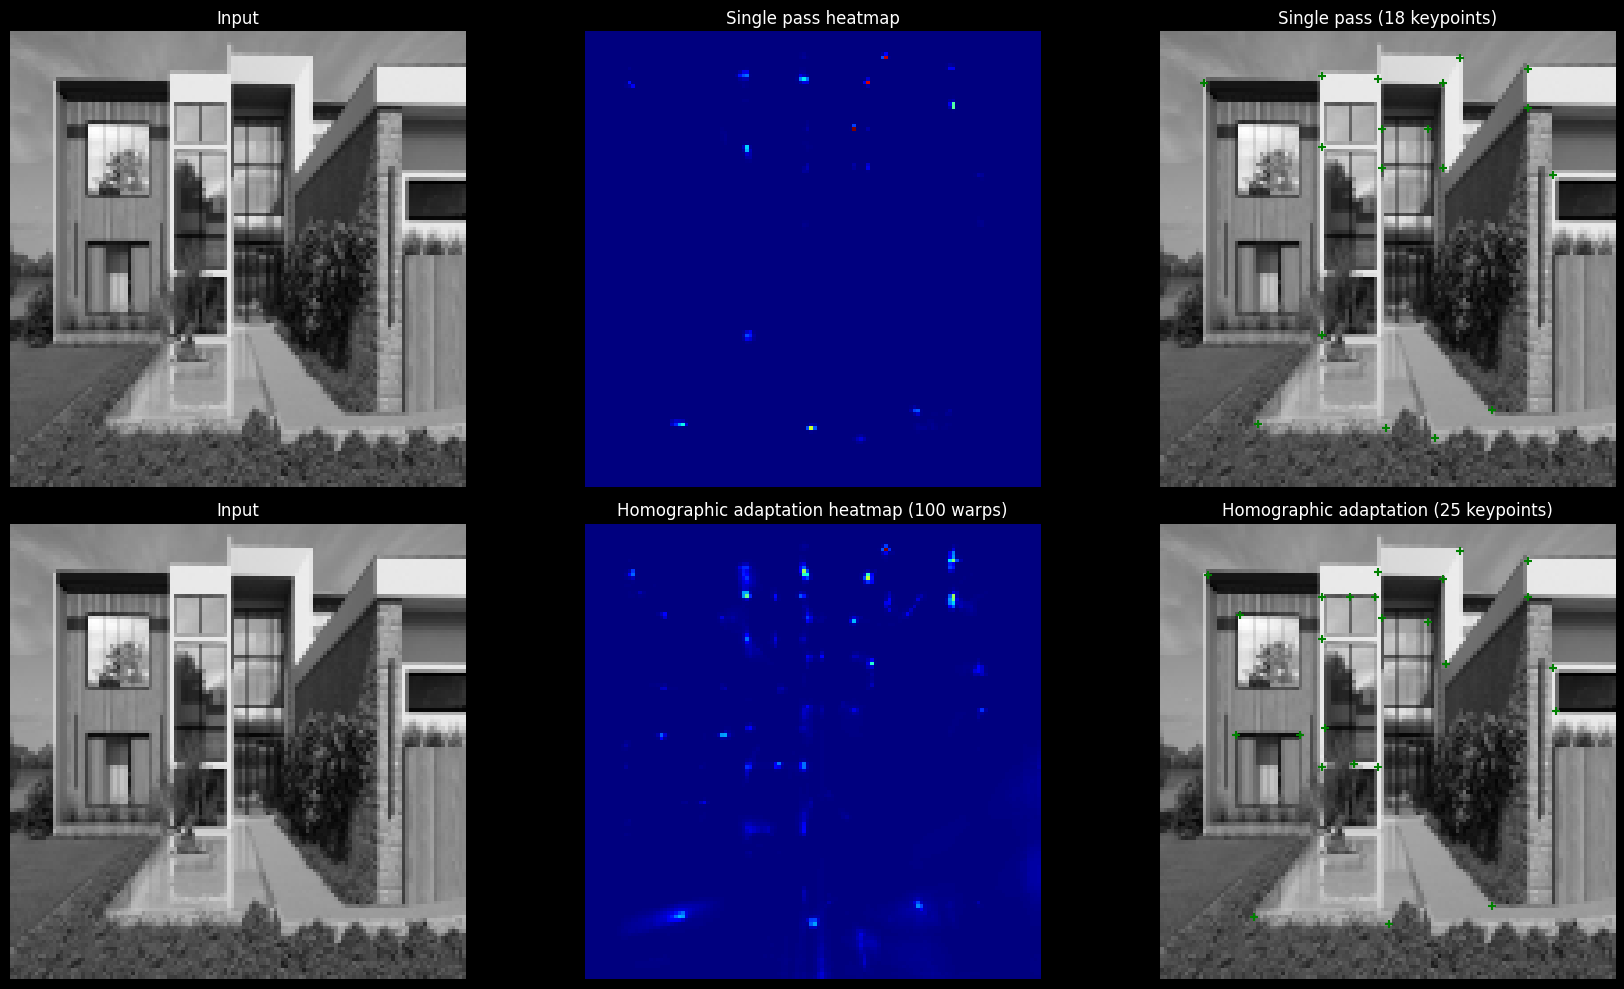

In [46]:
def predict_on_photo(path, model, num_homographies=99, percentile=99.5):
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(path)
    image = cv2.resize(image, (128, 128), interpolation=cv2.INTER_AREA)
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    image_tensor = torch.from_numpy(grayscale).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        heatmap_tensor = logits_to_heatmap(model(image_tensor))
    # homographic adaptation
    single_keypoints, single_heatmap = get_keypoints_from_heatmap(heatmap_tensor, percentile=percentile)
    adapted_heatmap = homographic_adaptation(model, grayscale, num_homographies=num_homographies)

    # keypoints from both heatmaps
    adapted_heatmap_tensor = torch.from_numpy(adapted_heatmap).unsqueeze(0).unsqueeze(0)
    adapted_keypoints, _ = get_keypoints_from_heatmap(adapted_heatmap_tensor, percentile=percentile)

    # plot results
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].imshow(grayscale, cmap='gray')
    axes[0, 0].set_title('Input')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(single_heatmap, cmap='jet')
    axes[0, 1].set_title('Single pass heatmap')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(grayscale, cmap='gray')
    for x, y in single_keypoints:
        axes[0, 2].plot(x, y, 'g+', ms=6, mew=1.5)
    axes[0, 2].set_title(f'Single pass ({len(single_keypoints)} keypoints)')
    axes[0, 2].axis('off')

    axes[1, 0].imshow(grayscale, cmap='gray')
    axes[1, 0].set_title('Input')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(adapted_heatmap, cmap='jet')
    axes[1, 1].set_title(f'Homographic adaptation heatmap ({num_homographies + 1} warps)')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(grayscale, cmap='gray')
    for x, y in adapted_keypoints:
        axes[1, 2].plot(x, y, 'g+', ms=6, mew=1.5)
    axes[1, 2].set_title(f'Homographic adaptation ({len(adapted_keypoints)} keypoints)')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig('real_photo_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()

    return single_keypoints, adapted_keypoints, single_heatmap, adapted_heatmap


single_keypoints, adapted_keypoints, single_heatmap, adapted_heatmap = predict_on_photo(
    'visualization/real_photo.jpg', model, num_homographies=99, percentile=99.5)
single_keypoints, adapted_keypoints, single_heatmap, adapted_heatmap = predict_on_photo(
    'visualization/real_photo2.jpg', model, num_homographies=99, percentile=99.5)